## Análisis Exploratorio del Dataset sobre Breast invasive carcinoma (TCGA-BRCA)

Los datos de la investigación fueron extraídos del  repositorio público de LinkedOmics y corresponden al estudio del cáncer de mama invasivo del proyecto TCGA-BRCA (https://www.linkedomics.org/data_download/TCGA-BRCA/). Los datos de trabajo son:

- Clinical: Matriz con anotaciones clínicas relevantes, compuesta por 1,097 muestras y 19 atributos clínicos. Permite segmentar la cohorte por variables como edad, etapa tumoral, supervivencia y otros fenotipos.

- RNAseq (HiSeq, Gene level): Matriz de expresión génica procesada a nivel de genes, donde cada celda contiene valores RSEM log-transformados (Log2(Val+1)). Incluye 1,093 muestras y 20,155 genes, lo que posibilita estudios de variabilidad, agrupamiento, análisis diferencial y modelado predictivo.

- SCNV (Gene level, log-ratio): Datos de cambios en el número de copias génicas, representados con log-ratios GISTIC2. Hay 1,080 muestras y 24,776 genes, permitiendo examinar variaciones estructurales y su impacto molecular en cáncer.

- Mutation (Gene level): Matriz binaria que indica la presencia de variantes somáticas (SNV) a nivel de genes, codificada por MutSig2CV. Incluye 975 muestras y 7,966 genes, útil para estudios de asociación genotipo-fenotipo y priorización de genes conductores.

In [212]:
# importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sksurv.metrics import concordance_index_censored
from sklearn.linear_model import LogisticRegression

In [213]:
# caminos
path_clinico = "data/Human__TCGA_BRCA__MS__Clinical__Clinical__01_28_2016__BI__Clinical__Firehose.tsi.txt"
path_genes = "data/Human__TCGA_BRCA__UNC__RNAseq__HiSeq_RNA__01_28_2016__BI__Gene__Firehose_RSEM_log2.cct"
path_scna = "data/Human__TCGA_BRCA__BI__SCNA__SNP_6.0__01_28_2016__BI__Gene__Firehose_GISTIC2.cct"
path_mutation = "data/Human__TCGA_BRCA__WUSM__Mutation__GAIIx__01_28_2016__BI__Gene__Firehose_MutSig2CV.cbt"

In [214]:
clin = pd.read_csv(path_clinico, sep='\t', index_col=0)
expr = pd.read_csv(path_genes, sep='\t', index_col=0)
scna = pd.read_csv(path_scna, sep='\t', index_col=0)
muta = pd.read_csv(path_mutation, sep='\t', index_col=0)

In [215]:
# se encuntran atributos x muestras
print(f"Dimensión datos expresión: {expr.shape}") 
print(f"Dimensión datos clínicos: {clin.shape}")
print(f"Dimensión datos scnv: {scna.shape}") 
print(f"Dimensión datos mutaciones: {muta.shape}")

Dimensión datos expresión: (20155, 1093)
Dimensión datos clínicos: (20, 1097)
Dimensión datos scnv: (24776, 1080)
Dimensión datos mutaciones: (7966, 975)


In [216]:
clin.head()

,TCGA.5L.AAT0,TCGA.5L.AAT1,TCGA.A1.A0SP,TCGA.A2.A04V,TCGA.A2.A04Y,TCGA.A2.A0CQ,TCGA.A2.A1G4,TCGA.A2.A25A,TCGA.A7.A0CD,TCGA.A7.A13G,...,TCGA.S3.AA11,TCGA.S3.AA14,TCGA.S3.AA15,TCGA.UL.AAZ6,TCGA.UU.A93S,TCGA.V7.A7HQ,TCGA.WT.AB44,TCGA.XX.A899,TCGA.XX.A89A,TCGA.Z7.A8R6
attrib_name,,,,,,,,,,,,,,,,,,,,,
years_to_birth,42,63,40,39,53,62,71,44,66,79,...,67,47,51,73,63,75,NaN,46,68,46
Tumor_purity,0.6501,0.5553,0.6913,0.8341,0.7318,0.7701,0.8879,0.595,0.8525,0.9357,...,0.7638,0.7492,0.5387,0.8031,0.8339,0.7774,0.7493,0.6069,0.6067,0.8143
pathologic_stage,stageii,stageiv,stageii,stageii,stageii,stagei,stageiii,stageii,stagei,stageii,...,stageii,stagei,stageii,stageii,stageiv,stageiii,stagei,stageiii,stageii,stagei
pathology_T_stage,t2,t2,t2,t2,t2,t1,t3,t2,t1,t2,...,t2,t1,t2,t2,t4,t1,t1,t1,t3,t1
pathology_N_stage,n0,n0,n0,n0,n1,n0,n1,n0,n0,n0,...,n0,n0,n1,n0,n3,n2,n0,n2,n0,n0


En función de los datos clínicos (según un análisis previo con el Data Wrangler) esta investigación se centrará en la construcción de un modelo que permita predecir si el paciente sobrevivirá tres o más en función de sus características.

In [217]:
expr.head()

,TCGA.3C.AAAU,TCGA.3C.AALI,TCGA.3C.AALJ,TCGA.3C.AALK,TCGA.4H.AAAK,TCGA.5L.AAT0,TCGA.5L.AAT1,TCGA.5T.A9QA,TCGA.A1.A0SB,TCGA.A1.A0SD,...,TCGA.UL.AAZ6,TCGA.UU.A93S,TCGA.V7.A7HQ,TCGA.W8.A86G,TCGA.WT.AB41,TCGA.WT.AB44,TCGA.XX.A899,TCGA.XX.A89A,TCGA.Z7.A8R5,TCGA.Z7.A8R6
attrib_name,,,,,,,,,,,,,,,,,,,,,
A1BG,7.6300,7.8971,8.7287,7.5851,8.0762,7.6779,7.7299,8.3001,5.6496,7.1629,...,5.4968,8.3353,10.0127,9.0608,6.9166,8.8835,7.8088,8.0008,8.7831,7.9619
A1CF,0.0000,0.0000,0.9310,0.0000,0.5115,0.0000,0.0000,0.6069,0.0000,0.0000,...,0.4846,0.0000,0.0000,0.5603,0.0000,0.0000,0.0000,1.7492,0.0000,0.0000
A2BP1,0.0000,0.0000,0.0000,0.0000,2.2720,0.6659,0.0000,0.6069,2.4607,0.4123,...,0.0000,0.0000,0.6922,2.6371,2.5190,0.0000,0.4789,1.2733,0.6756,0.0000
A2LD1,6.6999,6.1672,7.3422,5.9888,7.2796,6.8142,6.6861,7.8742,5.2816,6.0846,...,7.5688,7.8208,6.9794,5.9240,8.2903,5.9711,7.0469,6.3386,6.3628,4.7108
A2ML1,1.2501,2.4196,0.0000,1.4087,2.1389,1.1198,2.3434,0.0000,2.0543,3.1058,...,7.1771,0.0000,4.0885,1.2773,0.0000,2.9100,0.4789,5.8263,1.7610,2.3718


In [218]:
scna.head()

,TCGA.3C.AAAU,TCGA.3C.AALI,TCGA.3C.AALJ,TCGA.3C.AALK,TCGA.4H.AAAK,TCGA.5L.AAT0,TCGA.5L.AAT1,TCGA.5T.A9QA,TCGA.A1.A0SB,TCGA.A1.A0SD,...,TCGA.UL.AAZ6,TCGA.UU.A93S,TCGA.V7.A7HQ,TCGA.W8.A86G,TCGA.WT.AB41,TCGA.WT.AB44,TCGA.XX.A899,TCGA.XX.A89A,TCGA.Z7.A8R5,TCGA.Z7.A8R6
attrib_name,,,,,,,,,,,,,,,,,,,,,
ACAP3,0.069,-1.008,-0.33,-0.023,0.0,0.006,0.0,-0.647,0.002,-0.521,...,-0.052,-0.431,0.024,0.01,-0.503,-0.722,-0.071,-0.511,-0.153,-0.066
ACTRT2,0.069,-1.008,-0.33,-0.023,0.0,0.006,0.0,-0.647,0.002,-0.521,...,-0.052,-0.431,0.024,0.01,-0.503,-0.722,-0.071,-0.511,-0.153,-0.066
AGRN,0.069,-1.008,-0.33,-0.023,0.0,0.006,0.0,-0.647,0.002,-0.521,...,-0.052,-0.431,0.024,0.01,-0.503,-0.722,-0.071,-0.511,-0.153,-0.066
ANKRD65,0.069,-1.008,-0.33,-0.023,0.0,0.006,0.0,-0.647,0.002,-0.521,...,-0.052,-0.431,0.024,0.01,-0.503,-0.722,-0.071,-0.511,-0.153,-0.066
ATAD3A,0.069,-1.008,-0.33,-0.023,0.0,0.006,0.0,-0.647,0.002,-0.521,...,-0.052,-0.431,0.024,0.01,-0.503,-0.722,-0.071,-0.511,-0.153,-0.066


In [219]:
muta.head()

,TCGA.A8.A09Z,TCGA.AC.A2FB,TCGA.BH.A0HP,TCGA.D8.A1J8,TCGA.A8.A0A6,TCGA.AO.A03O,TCGA.AR.A1AJ,TCGA.BH.A18J,TCGA.E2.A1BC,TCGA.A8.A08G,...,TCGA.BH.A0HI,TCGA.B6.A0X0,TCGA.BH.A1FH,TCGA.BH.A1FR,TCGA.A8.A08C,TCGA.EW.A1P7,TCGA.A2.A3XW,TCGA.BH.A0DV,TCGA.A7.A0DC,TCGA.AC.A2FK
attrib_name,,,,,,,,,,,,,,,,,,,,,
A1CF,1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2BP1,0,0,0,0,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
A2ML1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AACS,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Cálculo de puntaje de microambientes

Mediante el algoritmo ESTIMATE (Estimation of STromal and Immune cells in MAlignant Tumor tissues using Expression data) se calcula: 
- Inmune Score: estimación de la infiltración de células inmunes en la muestra.
- Stromal Score: estimación de la presencia de células estromales.
- ESTIMATE Score: combinación que estima la pureza tumoral (negativamente correlacionada con las anteriores)

Los score se basan en el promedio de la expresión de genes característicos.

$$
\text{Score}_\text{immune} = \sum_{i \in G_{immune}} \text{Exp}_i
$$

$$
\text{Score}_\text{stromal} = \sum_{j \in G_{stromal}} \text{Exp}_j
$$

$$
S_{ESTIMATE} = S_{Immune} + S_{Stromal}
$$


donde $\text{Exp}_i$ es la expresión normalizada del gen marcador $i$.

In [220]:
immune_genes = [
    "ACAP1", "ADAM28", "ADGRE3", "ATM", "BST2", "CD247", "CD27", "CD2", "CD3D", "CD3E",
    "CD3G", "CD52", "CD53", "CD6", "CD7", "CD8A", "CD8B", "CLEC4A", "CLEC7A", "CXCL9",
    "CXCR3", "CYBB", "DOCK2", "FCER1G", "FGR", "FOXP3", "GBP1", "GBP2", "GBP4", "GBP5",
    "GZMA", "GZMB", "HLA-DMA", "HLA-DMB", "HLA-DOA", "HLA-DOB", "HLA-DPA1", "HLA-DPB1",
    "HLA-DQA1", "HLA-DQA2", "HLA-DQB1", "HLA-DQB2", "HLA-DRA", "HLA-DRB1", "HLA-DRB5",
    "IFI16", "IFIH1", "IFIT3", "IL10RA", "IL2RA", "IRF8", "LAPTM5", "LAIR1", "LCP2", "LILRB2",
    "LILRB4", "LYN", "MS4A1", "MPEG1", "MX1", "NCKAP1L", "NLRC4", "NOD2", "NRP1", "P2RY12",
    "PTPRC", "PTPN7", "PTPN22", "SASH3", "SIRPA", "SLA", "SLAMF6", "SPI1", "STAT1", "STAT4",
    "SYK", "TBX21", "TLR1", "TLR3", "TLR6", "TLR7", "TREM2", "TRIM21", "TRIM68", "TYROBP",
    "WAS", "ZAP70", "CLEC12A", "S1PR4", "SPN", "CXCL10", "CXCL11", "CCL4", "CCL5", "CCR5",
    "CCR7", "CD40LG", "ITGAL", "PACSIN1", "SH2D1A", "PRKCB", "TAP1", "TAP2", "TAPBP",
    "TRIM25", "CD274", "PDCD1", "CTLA4", "TIGIT", "ICOS", "FOXP3", "IL7R", "GZMK", "NAT2",
    "HLA-A", "HLA-B", "HLA-C", "IFIT3"
]

stromal_genes = [
    "ABI3", "ACVRL1", "ADAM12", "ADAMTS12", "AEBP1", "AGRN", "ANGPT1", "ANTXR1",
    "AQP1", "ASPN", "BGN", "BMP4", "CDH11", "COL1A1", "COL1A2", "COL3A1", "COL5A1",
    "COL5A2", "COL6A1", "COL6A2", "COL6A3", "COL8A1", "COL8A2", "COMP", "CRTAC1",
    "DDIT4", "DCN", "DPT", "ELN", "ENG", "FAP", "FBN1", "FBLN2", "FBN3", "FCN3", "FGF7",
    "FHL2", "FLI1", "FN1", "FOXC1", "GJA4", "GJA5", "GLT8D2", "GREM1", "HAPLN1",
    "HAS2", "HGF", "HLF", "ICAM1", "IGFBP5", "ITGA11", "ITGA8", "ITGAX", "ITGB8",
    "JAM2", "KCNJ8", "KDR", "LAMA1", "LAMA2", "LAMA4", "LAMB1", "LAMC1", "LMO2",
    "MMP2", "MMP3", "MMP11", "MMP14", "MMP16", "MMP9", "MXRA5", "MYH11",
    "NID2", "PDGFA", "PDGFRA", "PDGFRB", "PECAM1", "PLOD1", "POSTN", "PTGS2",
    "RGS5", "RSPO3", "SCRG1", "SEMA3A", "SERPINE1", "SIGLEC1", "SLC2A3", "SLIT2",
    "SMOC2", "SPON1", "SPARC", "SPP1", "STC1", "TCF21", "TGFB3", "TIMP1", "TNC",
    "TNXB", "TPM1", "TPM2", "VCAN", "VWF", "WISP1", "XDH", "ZEB1", "ZNF423"
]

Para el cálculo es necesario identificar los genes por tipo stromal o inmune según como se definen en https://www.frontiersin.org/journals/genetics/articles/10.3389/fgene.2022.840348/full

In [221]:
# filtrado de genes presentes en el dataset
immune_genes_present = [g for g in immune_genes if g in expr.index]
stromal_genes_present = [g for g in stromal_genes if g in expr.index]

print(f"Immune genes usados: {len(immune_genes_present)}")
print(f"Stromal genes usados: {len(stromal_genes_present)}")

# Calcular scores: promedio expresión de genes de cada set para cada muestra
immune_score = expr.loc[immune_genes_present].mean(axis=0)
stromal_score = expr.loc[stromal_genes_present].mean(axis=0)

# Score ESTIMATE, suma de scores
estimate_score = immune_score + stromal_score

# Unión en un DataFrame para análisis posterior
scores_df = pd.DataFrame({
    'immune_score': immune_score,
    'stromal_score': stromal_score,
    'estimate_score': estimate_score
})


Immune genes usados: 117
Stromal genes usados: 105


## Preprocesamiento de dataset de variables clínicas

trabajo como valores numéricos y el establecimiento de variables categoriales. La limpieza de los datos y eliminación de columnas innecesarias (la supervivencia está repetida)

In [222]:
clin = clin.T
clin.head()

attrib_name,years_to_birth,Tumor_purity,pathologic_stage,pathology_T_stage,pathology_N_stage,pathology_M_stage,histological_type,number_of_lymph_nodes,PAM50,ER.Status,PR.Status,HER2.Status,gender,radiation_therapy,race,ethnicity,Median_overall_survival,overall_survival,status,overallsurvival
TCGA.5L.AAT0,42,0.6501,stageii,t2,n0,m0,infiltratinglobularcarcinoma,0,NaN,NaN,NaN,NaN,female,yes,white,hispanicorlatino,0,1477,0,"1477,0"
TCGA.5L.AAT1,63,0.5553,stageiv,t2,n0,m1,infiltratinglobularcarcinoma,0,NaN,NaN,NaN,NaN,female,no,white,hispanicorlatino,0,1471,0,"1471,0"
TCGA.A1.A0SP,40,0.6913,stageii,t2,n0,m0,infiltratingductalcarcinoma,0,Basal,NaN,NaN,NaN,female,NaN,NaN,nothispanicorlatino,0,584,0,"584,0"
TCGA.A2.A04V,39,0.8341,stageii,t2,n0,m0,infiltratingductalcarcinoma,0,LumA,NaN,NaN,NaN,female,no,white,nothispanicorlatino,0,1920,1,"1920,1"
TCGA.A2.A04Y,53,0.7318,stageii,t2,n1,m0,infiltratingductalcarcinoma,1,LumB,NaN,NaN,NaN,female,yes,white,NaN,0,1099,0,"1099,0"


In [223]:
clin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1097 entries, TCGA.5L.AAT0 to TCGA.Z7.A8R6
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   years_to_birth           1082 non-null   object
 1   Tumor_purity             1086 non-null   object
 2   pathologic_stage         1075 non-null   object
 3   pathology_T_stage        1094 non-null   object
 4   pathology_N_stage        1077 non-null   object
 5   pathology_M_stage        934 non-null    object
 6   histological_type        1095 non-null   object
 7   number_of_lymph_nodes    929 non-null    object
 8   PAM50                    826 non-null    object
 9   ER.Status                104 non-null    object
 10  PR.Status                105 non-null    object
 11  HER2.Status              104 non-null    object
 12  gender                   1097 non-null   object
 13  radiation_therapy        1002 non-null   object
 14  race                     1

Algunas columnas del dataset clínico debido a la poca cantidad de datos no nulos que contienen no son relevantes para el estudio (ER.Status, PR.Status, HER2.Status). Además, la columna overrall_survival y Median_overral_survival proporcionan información asociada a overralsurvival que se hace innecesaria (la predicción se enfoca en si overralsurvival es mayor o no a tres años para x paciente).

In [224]:
clin = clin.drop(['ER.Status', 'PR.Status', 'HER2.Status', 'overall_survival', 'Median_overall_survival'], axis=1)

In [225]:
clin = clin.dropna(subset=['overallsurvival', 'status']) # eliminamos aquellos que no tengamos supervivencia y estado

In [226]:
clin['histological_type'].value_counts()

histological_type
infiltratingductalcarcinoma      747
infiltratinglobularcarcinoma     202
other,specify                     45
mixedhistology(pleasespecify)     30
mucinouscarcinoma                 17
metaplasticcarcinoma               7
medullarycarcinoma                 5
Name: count, dtype: int64

In [227]:
clin['overallsurvival'] = clin['overallsurvival'].str.replace(',', '.', regex=False)
for col in ["years_to_birth", "number_of_lymph_nodes", "Tumor_purity", "overallsurvival"]:
    clin[col] = pd.to_numeric(clin[col], errors='coerce')

# categoriales
categorical_cols = ['histological_type', 'status', 'race', 'ethnicity', 'gender', 'radiation_therapy', 'PAM50']
for col in categorical_cols:
    clin[col] = clin[col].astype('category')

clin['status'] = pd.to_numeric(clin['status'], errors='coerce') # llevar status a numérico
clin['status'] = clin['status'].astype(bool)

In [228]:
# Diccionario para mapear el estadio a números (ajusta si hay otros valores)
stage_map = {
    'stagei': 1,
    'stageii': 2,
    'stageiii': 3,
    'stageiv': 4,
    'stagev': 5
}
clin['pathologic_stage'] = clin['pathologic_stage'].map(stage_map)


In [229]:
# Diccionario de mapeo para los valores T
t_stage_map = {
    't1': 1,
    't2': 2,
    't3': 3,
    't4': 4
}

clin['pathology_T_stage'] = clin['pathology_T_stage'].map(t_stage_map)


In [230]:
n_stage_map = {
    'n0': 0,
    'n1': 1,
    'n2': 2,
    'n3': 3
}

clin['pathology_N_stage'] = clin['pathology_N_stage'].map(n_stage_map)


In [231]:
m_stage_map = {
    'm0': 0,
    'm1': 1
}

clin['pathology_M_stage'] = clin['pathology_M_stage'].map(m_stage_map)

In [232]:
clin.isna().sum()

attrib_name
years_to_birth            14
Tumor_purity              11
pathologic_stage          22
pathology_T_stage          3
pathology_N_stage         20
pathology_M_stage        162
histological_type          2
number_of_lymph_nodes    153
PAM50                    254
gender                     0
radiation_therapy         79
race                      87
ethnicity                165
status                     0
overallsurvival            0
dtype: int64

In [233]:
clin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1055 entries, TCGA.5L.AAT0 to TCGA.Z7.A8R6
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   years_to_birth         1041 non-null   float64 
 1   Tumor_purity           1044 non-null   float64 
 2   pathologic_stage       1033 non-null   float64 
 3   pathology_T_stage      1052 non-null   float64 
 4   pathology_N_stage      1035 non-null   float64 
 5   pathology_M_stage      893 non-null    float64 
 6   histological_type      1053 non-null   category
 7   number_of_lymph_nodes  902 non-null    float64 
 8   PAM50                  801 non-null    category
 9   gender                 1055 non-null   category
 10  radiation_therapy      976 non-null    category
 11  race                   968 non-null    category
 12  ethnicity              890 non-null    category
 13  status                 1055 non-null   bool    
 14  overallsurvival        105

In [235]:
clin = clin.dropna(subset=['histological_type'])

## Análisis estadístico de puntajes y supervivencia

Se comparan los puntajes con variables clínicas mediante pruebas como t-test y ANOVA. Con los pacientes agrupados por alto o bajo puntaje según la mediana se realizan análisis de supervivencia a través de curvas Kaplan-Meier (probabilidad de supervivencia) y Test log-rank (comparar diferencias entre grupos).

Mediante boxplots se puede visualizar la relación entre los tipos histológicos y los scores calculados anteriormente.


In [236]:
from scipy.stats import f_oneway, ttest_ind

samples_intersect = clin.index.intersection(scores_df.index)
clin_sub = clin.loc[samples_intersect]
scores_sub = scores_df.loc[samples_intersect]

print("Tipos histológicos disponibles:")
print(clin_sub['histological_type'].value_counts())

Tipos histológicos disponibles:
histological_type
infiltratingductalcarcinoma      745
infiltratinglobularcarcinoma     202
other,specify                     44
mixedhistology(pleasespecify)     29
mucinouscarcinoma                 17
metaplasticcarcinoma               7
medullarycarcinoma                 5
Name: count, dtype: int64


In [237]:
scores_sub.head()

,immune_score,stromal_score,estimate_score
TCGA.5L.AAT0,8.663220,10.331703,18.994923
TCGA.5L.AAT1,9.514657,9.888728,19.403385
TCGA.A1.A0SP,8.358671,9.442453,17.801124
TCGA.A2.A04V,7.230600,10.039542,17.270142
TCGA.A2.A04Y,8.652611,9.393628,18.046239


In [238]:
# ANOVA 
for score_name in ["stromal_score", "estimate_score", "immune_score"]:
    groups = [
        scores_sub.loc[clin_sub["histological_type"] == cat, score_name]
        for cat in clin_sub["histological_type"].unique()
    ]
    f_stat, p_val = f_oneway(*groups)
    print(
        f"ANOVA {score_name} entre tipos histológicos: F = {f_stat:.3f}, p = {p_val}"
    )

ANOVA stromal_score entre tipos histológicos: F = 14.622, p = 4.4081119712979827e-16
ANOVA estimate_score entre tipos histológicos: F = 12.653, p = 8.126332959954249e-14
ANOVA immune_score entre tipos histológicos: F = 7.971, p = 2.0031925385214153e-08


In [239]:
# t-test para variable binaria

if 'status' in clin_sub.columns:
    for score_name in ['stromal_score', 'estimate_score', 'immune_score']:
        g0 = scores_sub.loc[clin_sub['status'] == 0, score_name]
        g1 = scores_sub.loc[clin_sub['status'] == 1, score_name]
        t_stat, p_val = ttest_ind(g0, g1, equal_var=False)
        print(f"t-test {score_name} por status (0 vs 1): t = {t_stat:.3f}, p = {p_val}")
else:
    print("Variable 'status' no está disponible para t-test.")

t-test stromal_score por status (0 vs 1): t = 0.550, p = 0.5831004405217062
t-test estimate_score por status (0 vs 1): t = 1.967, p = 0.05062395703465421
t-test immune_score por status (0 vs 1): t = 2.620, p = 0.009446174898487151


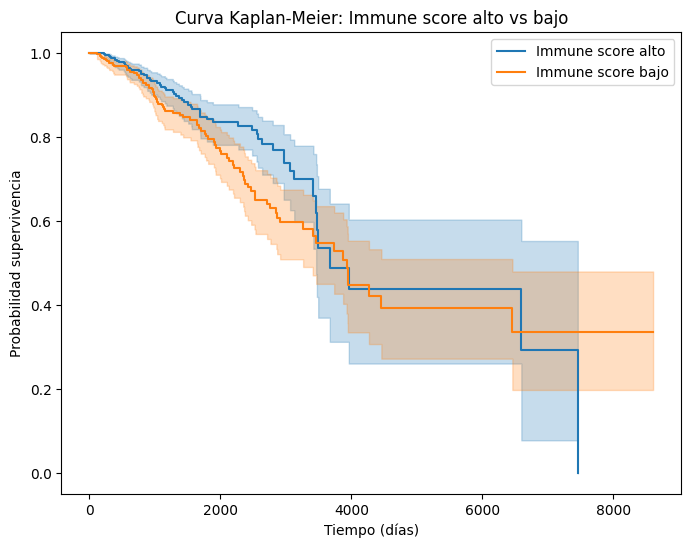

P-valor test log-rank (immune score): 0.0532


In [242]:
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Definir grupos high y low según mediana es común
median_immune = scores_sub['immune_score'].median()
high_immune = scores_sub['immune_score'] >= median_immune

# Supervivencia Kaplan-Meier para high vs low immune
kmf = KaplanMeierFitter()
T = clin_sub['overallsurvival']  # Tiempo supervivencia (ej: días)
E = clin_sub['status']  # Evento (1 muerto, 0 censurado)

plt.figure(figsize=(8,6))
kmf.fit(T[high_immune], event_observed=E[high_immune], label='Immune score alto')
ax = kmf.plot_survival_function()
kmf.fit(T[~high_immune], event_observed=E[~high_immune], label='Immune score bajo')
kmf.plot_survival_function(ax=ax)
plt.title('Curva Kaplan-Meier: Immune score alto vs bajo')
plt.xlabel('Tiempo (días)')
plt.ylabel('Probabilidad supervivencia')
plt.show()

# Test log-rank para comparar grupos
result_logrank = logrank_test(T[high_immune], T[~high_immune], event_observed_A=E[high_immune], event_observed_B=E[~high_immune])
print(f"P-valor test log-rank (immune score): {result_logrank.p_value:.4f}")


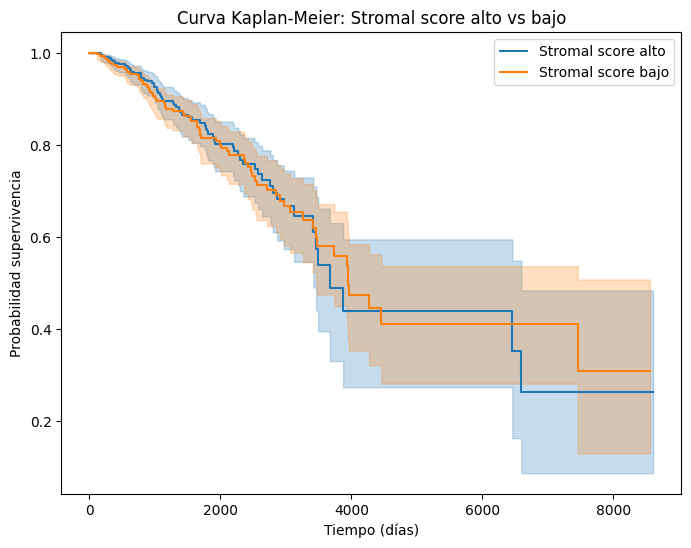

P-valor test log-rank (stromal score): 0.8152


In [243]:
# Definir grupos high y low según mediana es común
median_stromal = scores_sub['stromal_score'].median()
high_stromal = scores_sub['stromal_score'] >= median_stromal

plt.figure(figsize=(8,6))
kmf.fit(T[high_stromal], event_observed=E[high_stromal], label='Stromal score alto')
ax = kmf.plot_survival_function()
kmf.fit(T[~high_stromal], event_observed=E[~high_stromal], label='Stromal score bajo')
kmf.plot_survival_function(ax=ax)
plt.title('Curva Kaplan-Meier: Stromal score alto vs bajo')
plt.xlabel('Tiempo (días)')
plt.ylabel('Probabilidad supervivencia')
plt.show()

# Test log-rank para comparar grupos
result_logrank = logrank_test(T[high_stromal], T[~high_stromal], event_observed_A=E[high_stromal], event_observed_B=E[~high_stromal])
print(f"P-valor test log-rank (stromal score): {result_logrank.p_value:.4f}")

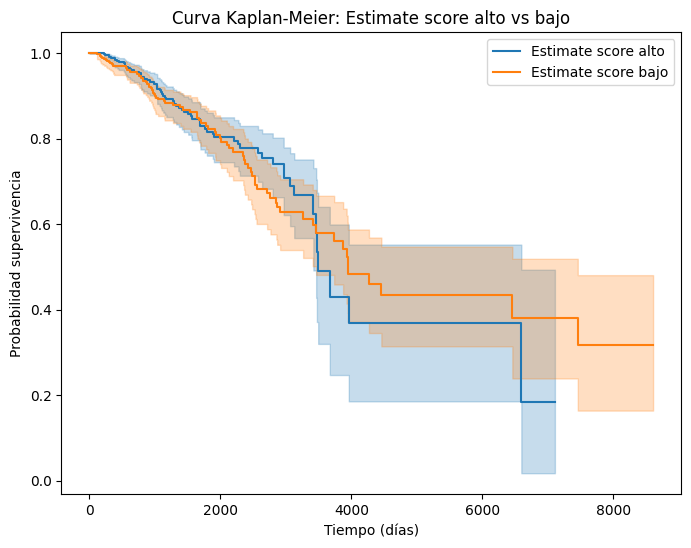

P-valor test log-rank (estimate score): 0.6685


In [244]:
# Definir grupos high y low según mediana es común
median_estimate = scores_sub['estimate_score'].median()
high_estimate = scores_sub['estimate_score'] >= median_estimate

plt.figure(figsize=(8,6))
kmf.fit(T[high_estimate], event_observed=E[high_estimate], label='Estimate score alto')
ax = kmf.plot_survival_function()
kmf.fit(T[~high_estimate], event_observed=E[~high_estimate], label='Estimate score bajo')
kmf.plot_survival_function(ax=ax)
plt.title('Curva Kaplan-Meier: Estimate score alto vs bajo')
plt.xlabel('Tiempo (días)')
plt.ylabel('Probabilidad supervivencia')
plt.show()

# Test log-rank para comparar grupos
result_logrank = logrank_test(T[high_estimate], T[~high_estimate], event_observed_A=E[high_estimate], event_observed_B=E[~high_estimate])
print(f"P-valor test log-rank (estimate score): {result_logrank.p_value:.4f}")

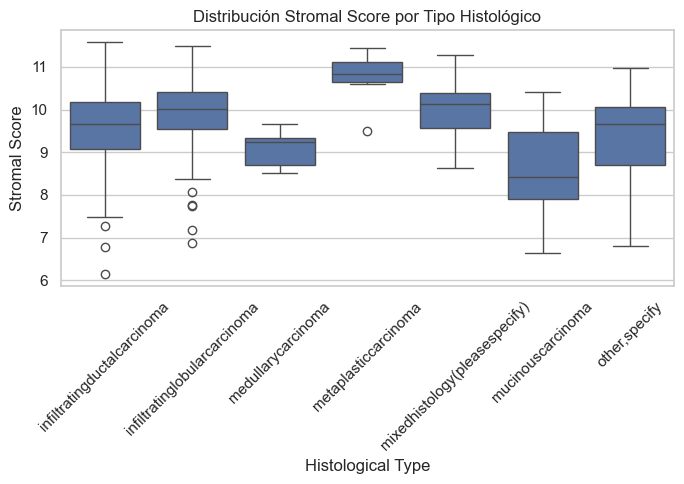

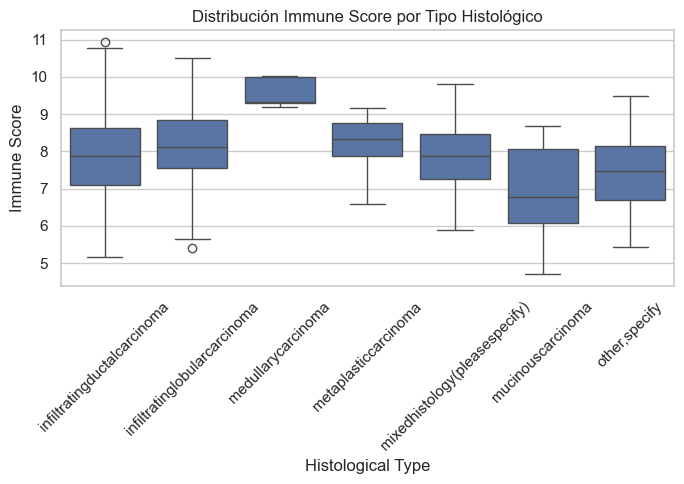

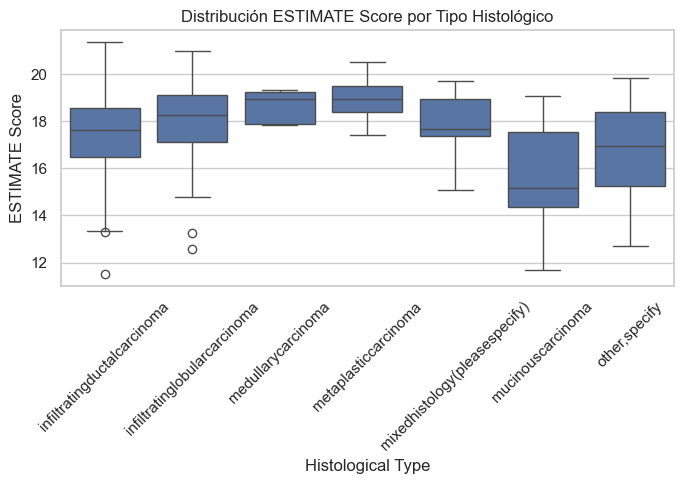

In [246]:
data = scores_sub.join(clin['histological_type'])
data = data.dropna(subset=['stromal_score', 'immune_score', 'estimate_score', 'histological_type'])

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Stromal Score
plt.figure(figsize=(7, 5))
sns.boxplot(x='histological_type', y='stromal_score', data=data)
plt.title('Distribución Stromal Score por Tipo Histológico')
plt.xlabel('Histological Type')
plt.ylabel('Stromal Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Immune Score
plt.figure(figsize=(7, 5))
sns.boxplot(x='histological_type', y='immune_score', data=data)
plt.title('Distribución Immune Score por Tipo Histológico')
plt.xlabel('Histological Type')
plt.ylabel('Immune Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ESTIMATE Score
plt.figure(figsize=(7, 5))
sns.boxplot(x='histological_type', y='estimate_score', data=data)
plt.title('Distribución ESTIMATE Score por Tipo Histológico')
plt.xlabel('Histological Type')
plt.ylabel('ESTIMATE Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Identificación de genes diferencialmente expresados (DEGs)

La identificación de genes diferencialemente expresados entre grupos alto y bajo puntajes immune y stromal mediante los siguientes criterios:
- $|\log_2(\text{FC})| > 1$ (Fold Change)
- FDR (False Discovery Rate) < 0.05

Son intersectadas las listas de DEGs comunes a ambos puntajes.

In [247]:
scores_sub.head()

,immune_score,stromal_score,estimate_score
TCGA.5L.AAT0,8.663220,10.331703,18.994923
TCGA.5L.AAT1,9.514657,9.888728,19.403385
TCGA.A1.A0SP,8.358671,9.442453,17.801124
TCGA.A2.A04V,7.230600,10.039542,17.270142
TCGA.A2.A04Y,8.652611,9.393628,18.046239


In [248]:
from scipy.stats import ttest_ind

common_samples = expr.columns.intersection(scores_sub.index)

# Subconjunto las muestras comunes para ambos datasets
expr_common = expr.loc[:, common_samples]
scores_sub_common = scores_sub.loc[common_samples]

scores_names = ['immune_score', 'stromal_score', 'estimate_score']

# Diccionarios para guardar resultados por score
deg_results = {}

for score_name in scores_names:
    print(f"Procesando DEGs para {score_name} ...")
    median_score = scores_sub_common[score_name].median()
    
    # Definir grupos alto y bajo para ese score
    high_group = scores_sub_common[score_name] >= median_score
    low_group = ~high_group
    
    # Seleccionar expresión para grupos alto/bajo (los genes están en filas)
    expr_high = expr_common.loc[:, high_group.index[high_group]].copy()
    expr_low = expr_common.loc[:, low_group.index[low_group]].copy()
    
    # Vectores para p-values y logFC
    pvals = []
    logFC = []
    genes = expr_common.index
    
    # Calcular t-test y fc para cada gen
    for gene in genes:
        group1 = expr_high.loc[gene].values
        group2 = expr_low.loc[gene].values
        
        # t-test con varianza desigual (Welch)
        stat, p = ttest_ind(group1, group2, equal_var=False)
        pvals.append(p)
        
        # Fold change promedio (diferencia de medias)
        fc = group1.mean() - group2.mean()  # log2 fold change si expresión es log2-transformada
        logFC.append(fc)
        
    # Crear DataFrame con resultados
    deg_df = pd.DataFrame({
        'gene': genes,
        'logFC': logFC,
        'p_value': pvals
    })
    
    # Corrección Bonferroni (ajuste simple)
    deg_df['adj_p_value'] = deg_df['p_value'] * len(deg_df)
    deg_df['adj_p_value'] = deg_df['adj_p_value'].clip(upper=1)  # corregir valores >1
    
    # Filtrar DEGs significativos: |logFC| > 1 y adj_p_value < 0.05
    deg_sig = deg_df[(deg_df['adj_p_value'] < 0.05) & (deg_df['logFC'].abs() > 1)].copy()
    deg_sig = deg_sig.sort_values('adj_p_value')
    
    # Guardar resultados
    deg_results[score_name] = {
        'all': deg_df,
        'significant': deg_sig
    }
    
    print(f"Score {score_name}: genes diferencialmente expresados significativos = {len(deg_sig)}")
    print(deg_sig.head(), '\n')

Procesando DEGs para immune_score ...
Score immune_score: genes diferencialmente expresados significativos = 989
          gene     logFC        p_value    adj_p_value
3246      CCR5  2.154183  5.379932e-202  1.084325e-197
15966     SLA2  2.497298  6.497271e-200  1.309525e-195
14356   PYHIN1  2.794641  2.818909e-199  5.681512e-195
14278    PTPN7  2.140238  5.653396e-198  1.139442e-193
8299   IL12RB1  2.213365  7.521363e-198  1.515931e-193 

Procesando DEGs para stromal_score ...
Score stromal_score: genes diferencialmente expresados significativos = 1103
          gene     logFC        p_value    adj_p_value
10179     LRP1  1.552514  5.122676e-172  1.032475e-167
10944     MMP2  1.951767  3.737158e-165  7.532242e-161
16733    SPARC  1.616137  8.625164e-163  1.738402e-158
629    ANGPTL2  1.612856  1.683346e-162  3.392784e-158
6625     FSTL1  1.546814  1.068296e-161  2.153150e-157 

Procesando DEGs para estimate_score ...
Score estimate_score: genes diferencialmente expresados significati

## Análisis funcional y enriquecimiento

Análisis de enriquecimiento funcional con:
- Gene Ontology: procesos biológicos, funciones moleculares y componentes celulares.
- KEGG: rutas metaólicas y de señalización.

In [249]:
import gseapy as gp

# Preparar lista de genes up-regulados y down-regulados
genes_up = deg_sig[deg_sig['logFC'] > 1]['gene'].tolist()
genes_down = deg_sig[deg_sig['logFC'] < -1]['gene'].tolist()

# Enriquecimiento KEGG por ejemplo para genes up
enr_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['KEGG_2021_Human'],
    organism='Human',
    outdir=None,  # no genera archivos
    cutoff=0.05
)
print("Enriquecimiento KEGG - genes UP regulados (top 5):")
print(enr_up.results.head())

Enriquecimiento KEGG - genes UP regulados (top 5):
          Gene_set                                               Term Overlap  \
0  KEGG_2021_Human             Cytokine-cytokine receptor interaction  99/295   
1  KEGG_2021_Human                         Hematopoietic cell lineage   52/99   
2  KEGG_2021_Human  Viral protein interaction with cytokine and cy...  51/100   
3  KEGG_2021_Human                            Cell adhesion molecules  54/148   
4  KEGG_2021_Human                        Chemokine signaling pathway  60/192   

        P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  \
0  2.823718e-42      7.567563e-40            0                     0   
1  3.368752e-34      4.514128e-32            0                     0   
2  9.740897e-33      8.701868e-31            0                     0   
3  1.417446e-25      9.496886e-24            0                     0   
4  3.550895e-24      1.903280e-22            0                     0   

   Odds Ratio  Combined Score

In [250]:
# Enriquecimiento GO para genes up regulados (BP, CC, MF)
enr_go_bp_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['GO_Biological_Process_2025'],
    organism='Human',
    outdir=None,
    cutoff=0.05
)
print("Enriquecimiento GO BP - genes UP regulados (top 5):")
print(enr_go_bp_up.results.head())

enr_go_cc_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['GO_Cellular_Component_2025'],
    organism='Human',
    outdir=None,
    cutoff=0.05
)
print("Enriquecimiento GO CC - genes UP regulados (top 5):")
print(enr_go_cc_up.results.head())

enr_go_mf_up = gp.enrichr(
    gene_list=genes_up,
    gene_sets=['GO_Molecular_Function_2025'],
    organism='Human',
    outdir=None,
    cutoff=0.05
)
print("Enriquecimiento GO MF - genes UP regulados (top 5):")
print(enr_go_mf_up.results.head())

Enriquecimiento GO BP - genes UP regulados (top 5):
                     Gene_set  \
0  GO_Biological_Process_2025   
1  GO_Biological_Process_2025   
2  GO_Biological_Process_2025   
3  GO_Biological_Process_2025   
4  GO_Biological_Process_2025   

                                                Term Overlap       P-value  \
0                 Inflammatory Response (GO:0006954)  87/261  5.520583e-37   
1  Positive Regulation of Cytokine Production (GO...  93/325  1.878551e-33   
2   Cytokine-Mediated Signaling Pathway (GO:0019221)  81/255  8.422124e-33   
3  Positive Regulation of T Cell Activation (GO:0...  50/111  7.465485e-29   
4    Regulation of T Cell Proliferation (GO:0042129)   43/83  3.585519e-28   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0      1.921163e-33            0                     0    7.121236   
1      3.268679e-30            0                     0    5.717804   
2      9.769664e-30            0                     0    6.599539   


## Red de interacción proteica (PPI) y selección de genes hub 

Se construye una red PPI con datos STRING (interacciones con score mayor a 0.9). Son identificados 25 genes hub con mayor centralidad evaluando según el grado de cada gen en la red. Estos genes están asociados a procesos inmunes claves. 

In [252]:
import requests

def chunk_list(lst, n):
    """Divide una lista en sublistas de tamaño máximo n."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

def get_string_edges(genes, species=9606, min_score=900, batch_size=50):
    """
    Consulta a la API STRING para obtener interacciones
    genes: lista de genes (símbolos)
    species: 9606 para humano
    min_score: umbral mínimo de confiabilidad (900 = 0.9)
    batch_size: cantidad máxima de genes por llamada
    Retorna lista de tuplas (protein1, protein2)
    """
    all_edges = []
    genes_upper = set(g.upper() for g in genes)

    for batch in chunk_list(genes, batch_size):
        genes_str = "%0d".join(batch)
        url = f"https://string-db.org/api/tsv/network?identifiers={genes_str}&species={species}&required_score={min_score}"
        response = requests.get(url)

        if response.ok:
            lines = response.text.strip().split('\n')
            # Saltar cabezera
            for line in lines[1:]:
                fields = line.split('\t')
                protein1 = fields[2].upper()
                protein2 = fields[3].upper()
                if protein1 in genes_upper and protein2 in genes_upper:
                    all_edges.append((protein1, protein2))
        else:
            print(f"Error al consultar STRING API para batch {batch[0]}-{batch[-1]}: Código {response.status_code}")

    return all_edges

# Ejemplo: usar genes up regulados para obtener aristas
edges_up = get_string_edges(genes_up, batch_size=50)

print(f"Aristas (interacciones) obtenidas para genes up: {len(edges_up)}")
print("Primeras 10 aristas:")
print(edges_up[:10])


Aristas (interacciones) obtenidas para genes up: 149
Primeras 10 aristas:
[('CD4', 'HLA-DMB'), ('CD4', 'PDCD1LG2'), ('CD4', 'PTPRC'), ('CD4', 'CD3G'), ('CD4', 'CD5'), ('CD4', 'IL16'), ('CD4', 'CCR5'), ('LCP2', 'PTPRC'), ('LCP2', 'ITK'), ('LCP2', 'BTK')]


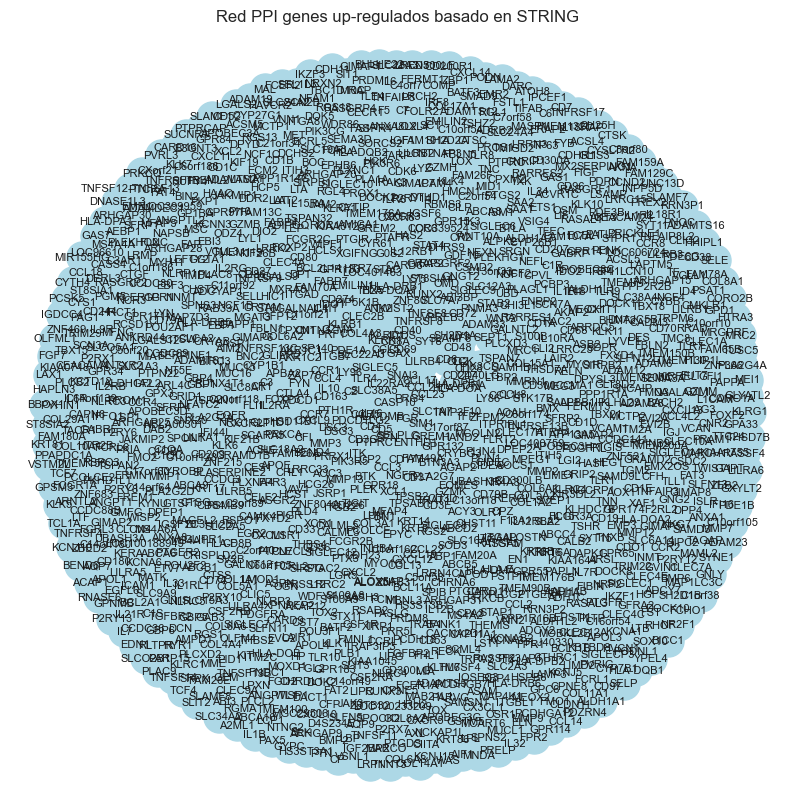

In [253]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(genes_up)
G.add_edges_from(edges_up)

plt.figure(figsize=(10,10))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Red PPI genes up-regulados basado en STRING")
plt.axis('off')
plt.show()


In [254]:
degree_dict = dict(G.degree)
# Ordenar genes por grado descendente
hub_genes_sorted = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
top_hubs = [gene for gene, deg in hub_genes_sorted[:100]]  # por ejemplo, top 100

print(f"Top {len(top_hubs)} genes hub seleccionados: {top_hubs}")


Top 100 genes hub seleccionados: ['CD4', 'CD8A', 'CD247', 'CD48', 'CD28', 'CD2', 'LCK', 'LCP2', 'SPN', 'PTPRC', 'ITK', 'HLA-DRA', 'SH2D1A', 'HLA-DPB1', 'HLA-DOA', 'CD3D', 'CD40', 'CTLA4', 'RASSF5', 'ITGAL', 'FBN1', 'COL3A1', 'PLIN1', 'BTK', 'CD3G', 'CD5', 'LY9', 'SLAMF6', 'CD3E', 'TRAT1', 'CD226', 'GZMK', 'CD27', 'CD86', 'GZMA', 'TNFRSF9', 'KLRK1', 'KLRD1', 'TNFRSF8', 'ICOS', 'FYN', 'FOXP3', 'C1QB', 'C1QA', 'C1QC', 'CD79A', 'IL10', 'CCL4', 'ITGA4', 'ITGAM', 'CXCL12', 'CCL19', 'IDO1', 'CCL21', 'LUM', 'COL5A2', 'ADH1A', 'ADH1B', 'ADH1C', 'ADIPOQ', 'CIDEA', 'CIDEC', 'KRT16', 'WIPF1', 'EVI2B', 'HCLS1', 'IL16', 'PLEK', 'PIK3R5', 'SELPLG', 'EVI2A', 'CCR5', 'CARD11', 'HLA-DMB', 'PRKCB', 'PDCD1LG2', 'APBB1IP', 'FERMT3', 'CD6', 'PIK3CD', 'CD40LG', 'ITGB2', 'CXCR3', 'EOMES', 'TIGIT', 'CXCR6', 'KCNA3', 'CYBB', 'PRF1', 'NCF4', 'KLRB1', 'KCNAB2', 'HLA-E', 'HLA-DMA', 'ITGAX', 'CTSS', 'TNFSF8', 'SPI1', 'IRF4', 'CD74']


## Dataset combinacion clinico con expresión de genes más relevantes

In [257]:
# Preparamos DataFrame de expresión transpuesta: muestras filas, genes columnas
expr_T = expr.loc[top_hubs].T

common_samples = expr_T.index.intersection(clin.index)
print(f"Cantidad de muestras comunes: {len(common_samples)}")

expr_T_sub = expr_T.loc[common_samples]
clin_sub = clin.loc[common_samples]

data = expr_T.join(clin_sub[['overallsurvival', 'status']])

# Eliminar muestras con datos faltantes
data = data.dropna()

Cantidad de muestras comunes: 1049


In [259]:
# Definir supervivencia binaria a 3 años (1095 días)
data['survival_3yr'] = (data['overallsurvival'] >= 1095).astype(int)

from sklearn.preprocessing import OneHotEncoder

# Suponiendo que clin_sub y data_cox ya están definidos, y ambos tienen el mismo índice y número de filas

# 1. Codifica histological_type en clin_sub
encoder = OneHotEncoder(sparse_output=False) 
encoded_cols = encoder.fit_transform(clin_sub[['histological_type']])

# Verifica las categorías codificadas
print("Categorías detectadas:", encoder.categories_)

# 2. Convierte el array en DataFrame y conserva el índice original
encoded_df = pd.DataFrame(
    encoded_cols, 
    columns=encoder.get_feature_names_out(['histological_type']), 
    index=clin_sub.index
)

# 3. Une las columnas codificadas a data
data = pd.concat([data, encoded_df], axis=1)

# 4. Guarda el DataFrame en el archivo deseado
data.to_csv('data/data_with_survival3yr_ht_brca.csv', index=True)

print("Archivo CSV guardado en 'data/data_with_survival3yr_ht.csv'")


Categorías detectadas: [array(['infiltratingductalcarcinoma', 'infiltratinglobularcarcinoma',
       'medullarycarcinoma', 'metaplasticcarcinoma',
       'mixedhistology(pleasespecify)', 'mucinouscarcinoma',
       'other,specify'], dtype=object)]
Archivo CSV guardado en 'data/data_with_survival3yr_ht.csv'


In [260]:
data.head()

,CD4,CD8A,CD247,CD48,CD28,CD2,LCK,LCP2,SPN,PTPRC,...,overallsurvival,status,survival_3yr,histological_type_infiltratingductalcarcinoma,histological_type_infiltratinglobularcarcinoma,histological_type_medullarycarcinoma,histological_type_metaplasticcarcinoma,histological_type_mixedhistology(pleasespecify),histological_type_mucinouscarcinoma,"histological_type_other,specify"
TCGA.3C.AAAU,8.8185,4.2936,4.2155,6.2175,4.1885,4.9045,5.2034,7.3178,6.5071,7.8029,...,4047.0,False,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
TCGA.3C.AALI,10.4047,9.4247,7.6203,8.4849,6.1527,9.1515,8.4539,8.9897,8.0395,10.0082,...,4005.0,False,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA.3C.AALJ,10.5608,8.9436,7.4216,8.4212,6.4300,8.8784,8.0088,8.8390,7.9571,10.0072,...,1474.0,False,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA.3C.AALK,10.0961,7.2868,6.8165,7.8623,5.5266,8.0631,7.3393,8.4140,7.7251,9.2380,...,1448.0,False,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA.4H.AAAK,10.2438,6.6942,5.8264,7.1824,6.8191,7.5790,6.8136,8.3322,7.2566,9.3768,...,348.0,False,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [262]:
data.shape

(1049, 110)